In [43]:
from dataUtils import *
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.gridspec as gridspec
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
%matplotlib inline

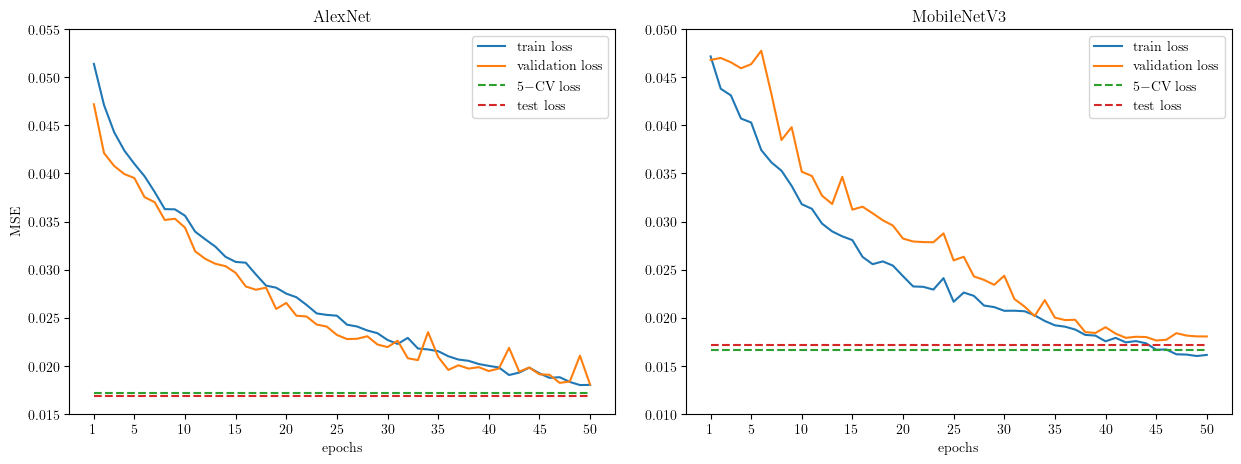

In [53]:
models = ['alex','mobile']
_,axs = plt.subplots(1,2,figsize=(15,5))
plt.subplots_adjust(wspace=0.13)
for i,model in enumerate(models):
    epochs_loss = load_json(f'results/{model}net.json')
    epochs = len(epochs_loss['validation'])
    cv = epochs_loss['cv']
    test = epochs_loss['test']
    first_epoch = 1
    epochsX = range(first_epoch,epochs+1)
    axs[i].plot(epochsX, epochs_loss['train'][first_epoch-1:], label='train loss')
    axs[i].plot(epochsX, epochs_loss['validation'][first_epoch-1:], label='validation loss')
    axs[i].plot([first_epoch,epochs], [cv]*2,'--' ,label='$5-$CV loss')
    axs[i].plot([first_epoch,epochs], [test]*2,'--' ,label='test loss')
    axs[i].set_xticks([1]+list(range(5,epochs+1,5)))
    axs[i].set_yticks([round(x,3) for x in axs[i].get_yticks()])
    axs[i].set_xlabel('epochs')
    axs[i].legend()
    if i==0: axs[i].set_ylabel('MSE')
axs[0].set_title('AlexNet')
axs[1].set_title('MobileNetV3')
# axs[2].set_title('SqueezeNet')
plt.savefig('learning_curves.pdf',bbox_inches='tight')

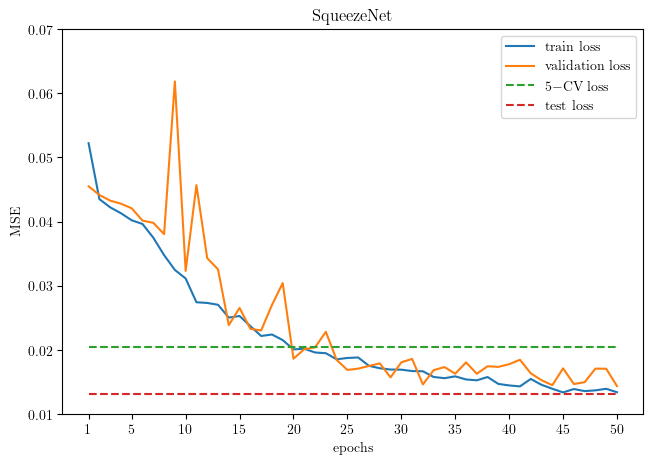

In [58]:
_,ax = plt.subplots(1,1,figsize=(7.5,5))
epochs_loss = load_json(f'results/squeezenet.json')
epochs = len(epochs_loss['validation'])
cv = epochs_loss['cv']
test = epochs_loss['test']
first_epoch = 1
epochsX = range(first_epoch,epochs+1)
ax.plot(epochsX, epochs_loss['train'][first_epoch-1:], label='train loss')
ax.plot(epochsX, epochs_loss['validation'][first_epoch-1:], label='validation loss')
ax.plot([first_epoch,epochs], [cv]*2,'--' ,label='$5-$CV loss')
ax.plot([first_epoch,epochs], [test]*2,'--' ,label='test loss')
ax.set_xticks([1]+list(range(5,epochs+1,5)))
ax.set_yticks([round(x,3) for x in ax.get_yticks()])
ax.set_xlabel('epochs')
ax.legend()
ax.set_ylabel('MSE')
ax.set_title('SqueezeNet')
plt.savefig('learning_curves2.pdf',bbox_inches='tight')